In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from scipy.stats import genextreme
import warnings
warnings.filterwarnings('ignore')

# Load existing coefficient arrays
a_zeta = np.load('a_zeta.npy')
a_f_rand = np.load('a_f_rand.npy')
a_f_fully_rand = np.load('a_f_fully_rand.npy')
a_f_alt = np.load('a_f_alt.npy')
N_max = np.load('N_max.npy')

print(f"Loaded coefficient arrays up to N = {N_max}")
print(f"a_zeta shape: {a_zeta.shape}")
print(f"a_f_rand shape: {a_f_rand.shape}")
print(f"a_f_fully_rand shape: {a_f_fully_rand.shape}")
print(f"a_f_alt shape: {a_f_alt.shape}")


Loaded coefficient arrays up to N = 100000
a_zeta shape: (100001,)
a_f_rand shape: (100001,)
a_f_fully_rand shape: (100001,)
a_f_alt shape: (100001,)


In [2]:

# Analysis Plan:
# 1. Generate coefficients for L(s, χ₄) with real character mod 5
# 2. Generate coefficients for validated L_DH (using ε=0 from r71 description: a_n = (-1)^ω(n) for squarefree n)
# 3. Compute M_coh(t) time series for all 5 functions at N=10^4 for two t-ranges:
# - Low-t: [50, 550]
# - High-t: [10000, 20000]
# 4. Extract block maxima (at least 100) from each time series
# 5. Fit GEV distribution to each set of block maxima
# 6. Calculate Δξ = ξ_high - ξ_low for each function
# 7. Create summary plot showing Δξ for all functions

# First, let's generate the missing coefficients

# Helper functions
def is_squarefree(n):
 """Check if n is squarefree"""
 if n <= 1:
 return n == 1
 i = 2
 while i * i <= n:
 if n % (i * i) == 0:
 return False
 i += 1
 return True

def omega(n):
 """Count number of distinct prime factors"""
 if n <= 1:
 return 0
 count = 0
 temp_n = n
 i = 2
 while i * i <= temp_n:
 if temp_n % i == 0:
 count += 1
 while temp_n % i == 0:
 temp_n //= i
 i += 1
 if temp_n > 1:
 count += 1
 return count

# Generate L(s, χ₄) with real character mod 5
# The real character mod 5 is: χ(n) = (n/5) where (n/5) is the Legendre symbol
# χ(1)=1, χ(2)=-1, χ(3)=-1, χ(4)=1, χ(0)=0
def chi_mod5(n):
 """Real character mod 5 (Legendre symbol)"""
 n_mod = n % 5
 if n_mod == 0:
 return 0
 elif n_mod == 1 or n_mod == 4:
 return 1
 else: # n_mod == 2 or n_mod == 3
 return -1

print("Generating L(s, χ₄) coefficients (real character mod 5)...")
a_L_chi4 = np.array([chi_mod5(n) for n in range(N_max + 1)])
print(f"a_L_chi4 shape: {a_L_chi4.shape}")
print(f"First 20 coefficients: {a_L_chi4[:20]}")


Generating L(s, χ₄) coefficients (real character mod 5)...
a_L_chi4 shape: (100001,)
First 20 coefficients: [ 0 1 -1 -1 1 0 1 -1 -1 1 0 1 -1 -1 1 0 1 -1 -1 1]


In [3]:

# Generate validated L_DH coefficients
# According to the dataset description, L_DH^(ε=0) from r71 uses: a_n = (-1)^ω(n) for squarefree n, 0 otherwise
# This should match a_f_alt definition: μ(n)² × (-1)^ω(n)
# where μ(n)² = 1 if n is squarefree, 0 otherwise

print("Generating validated L_DH coefficients (ε=0 version)...")
a_L_DH = np.zeros(N_max + 1)
for n in range(1, N_max + 1):
 if is_squarefree(n):
 a_L_DH[n] = (-1) ** omega(n)

print(f"a_L_DH shape: {a_L_DH.shape}")
print(f"First 20 coefficients: {a_L_DH[:20]}")

# Verify this matches a_f_alt
print(f"\nVerification: a_L_DH matches a_f_alt? {np.allclose(a_L_DH, a_f_alt)}")
print(f"First 20 a_f_alt: {a_f_alt[:20]}")


Generating validated L_DH coefficients (ε=0 version)...


a_L_DH shape: (100001,)
First 20 coefficients: [ 0. 1. -1. -1. 0. -1. 1. -1. 0. 0. 1. -1. 0. -1. 1. 1. 0. -1.
 0. -1.]

Verification: a_L_DH matches a_f_alt? True
First 20 a_f_alt: [ 0. 1. -1. -1. 0. -1. 1. -1. 0. 0. 1. -1. 0. -1. 1. 1. 0. -1.
 0. -1.]


In [4]:

# Now compute M_coh(t) time series for all 5 functions
# M_coh(t; N) is the magnitude of the partial sum D_F(t; N) = Σ_{n≤N} a_n(F) / n^(1/2 + it)
# We'll use N = 10^4 as specified

N = 10000

# Function to compute D_F(t; N) using Kahan summation for numerical precision
def compute_D_F(t_array, a_coeffs, N):
 """
 Compute D_F(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)
 Returns complex array of same shape as t_array
 """
 result = np.zeros(len(t_array), dtype=complex)
 
 for idx, t in enumerate(t_array):
 # Kahan compensated summation
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 
 for n in range(1, N + 1):
 if a_coeffs[n] != 0:
 # Compute a_n / n^(1/2 + it) = a_n * n^(-1/2) * exp(-it * log(n))
 term = a_coeffs[n] * (n ** (-0.5)) * np.exp(-1j * t * np.log(n))
 y = term - c
 temp = s + y
 c = (temp - s) - y
 s = temp
 
 result[idx] = s
 
 return result

# Function to compute M_coh(t)
def compute_M_coh(t_array, a_coeffs, N):
 """
 Compute M_coh(t; N) = |D_F(t; N)|
 """
 D_F = compute_D_F(t_array, a_coeffs, N)
 return np.abs(D_F)

print(f"Computing M_coh time series at N = {N}")
print("This may take a few minutes...")

# Define t-ranges
# Low-t: [50, 550], use dt = 0.5 for good resolution
t_low = np.arange(50, 550.5, 0.5)
# High-t: [10000, 20000], use dt = 1.0 for computational efficiency
t_high = np.arange(10000, 20001, 1.0)

print(f"Low-t range: {len(t_low)} points from {t_low[0]} to {t_low[-1]}")
print(f"High-t range: {len(t_high)} points from {t_high[0]} to {t_high[-1]}")


Computing M_coh time series at N = 10000
This may take a few minutes...
Low-t range: 1001 points from 50.0 to 550.0
High-t range: 10001 points from 10000.0 to 20000.0


In [5]:

# Compute M_coh for ζ function (low-t range)
print("Computing M_coh for ζ (zeta) - Low-t range...")
M_coh_zeta_low = compute_M_coh(t_low, a_zeta, N)
print(f" Mean: {np.mean(M_coh_zeta_low):.4f}, Max: {np.max(M_coh_zeta_low):.4f}, Min: {np.min(M_coh_zeta_low):.4f}")


Computing M_coh for ζ (zeta) - Low-t range...


 Mean: 1.7543, Max: 8.3653, Min: 0.0124


In [6]:

# Compute M_coh for ζ function (high-t range)
print("Computing M_coh for ζ (zeta) - High-t range...")
M_coh_zeta_high = compute_M_coh(t_high, a_zeta, N)
print(f" Mean: {np.mean(M_coh_zeta_high):.4f}, Max: {np.max(M_coh_zeta_high):.4f}, Min: {np.min(M_coh_zeta_high):.4f}")


Computing M_coh for ζ (zeta) - High-t range...


 Mean: 1.9213, Max: 19.7896, Min: 0.0022


In [7]:

# Compute M_coh for L(s, χ₄) mod 5
print("Computing M_coh for L(s, χ₄) mod 5 - Low-t range...")
M_coh_Lchi4_low = compute_M_coh(t_low, a_L_chi4, N)
print(f" Mean: {np.mean(M_coh_Lchi4_low):.4f}, Max: {np.max(M_coh_Lchi4_low):.4f}, Min: {np.min(M_coh_Lchi4_low):.4f}")

print("Computing M_coh for L(s, χ₄) mod 5 - High-t range...")
M_coh_Lchi4_high = compute_M_coh(t_high, a_L_chi4, N)
print(f" Mean: {np.mean(M_coh_Lchi4_high):.4f}, Max: {np.max(M_coh_Lchi4_high):.4f}, Min: {np.min(M_coh_Lchi4_high):.4f}")


Computing M_coh for L(s, χ₄) mod 5 - Low-t range...


 Mean: 1.7057, Max: 10.7856, Min: 0.0009
Computing M_coh for L(s, χ₄) mod 5 - High-t range...


 Mean: 1.9374, Max: 18.5527, Min: 0.0050


In [8]:

# Compute M_coh for f_rand
print("Computing M_coh for f_rand - Low-t range...")
M_coh_frand_low = compute_M_coh(t_low, a_f_rand, N)
print(f" Mean: {np.mean(M_coh_frand_low):.4f}, Max: {np.max(M_coh_frand_low):.4f}, Min: {np.min(M_coh_frand_low):.4f}")

print("Computing M_coh for f_rand - High-t range...")
M_coh_frand_high = compute_M_coh(t_high, a_f_rand, N)
print(f" Mean: {np.mean(M_coh_frand_high):.4f}, Max: {np.max(M_coh_frand_high):.4f}, Min: {np.min(M_coh_frand_high):.4f}")


Computing M_coh for f_rand - Low-t range...


 Mean: 2.0117, Max: 19.7724, Min: 0.0094
Computing M_coh for f_rand - High-t range...


 Mean: 2.0562, Max: 34.0068, Min: 0.0075


In [9]:

# Compute M_coh for f_fully_rand
print("Computing M_coh for f_fully_rand - Low-t range...")
M_coh_ffullyrand_low = compute_M_coh(t_low, a_f_fully_rand, N)
print(f" Mean: {np.mean(M_coh_ffullyrand_low):.4f}, Max: {np.max(M_coh_ffullyrand_low):.4f}, Min: {np.min(M_coh_ffullyrand_low):.4f}")

print("Computing M_coh for f_fully_rand - High-t range...")
M_coh_ffullyrand_high = compute_M_coh(t_high, a_f_fully_rand, N)
print(f" Mean: {np.mean(M_coh_ffullyrand_high):.4f}, Max: {np.max(M_coh_ffullyrand_high):.4f}, Min: {np.min(M_coh_ffullyrand_high):.4f}")


Computing M_coh for f_fully_rand - Low-t range...


 Mean: 2.2798, Max: 7.4947, Min: 0.1189
Computing M_coh for f_fully_rand - High-t range...


 Mean: 2.2772, Max: 8.1411, Min: 0.0165


In [10]:

# Compute M_coh for L_DH
print("Computing M_coh for L_DH - Low-t range...")
M_coh_LDH_low = compute_M_coh(t_low, a_L_DH, N)
print(f" Mean: {np.mean(M_coh_LDH_low):.4f}, Max: {np.max(M_coh_LDH_low):.4f}, Min: {np.min(M_coh_LDH_low):.4f}")

print("Computing M_coh for L_DH - High-t range...")
M_coh_LDH_high = compute_M_coh(t_high, a_L_DH, N)
print(f" Mean: {np.mean(M_coh_LDH_high):.4f}, Max: {np.max(M_coh_LDH_high):.4f}, Min: {np.min(M_coh_LDH_high):.4f}")


Computing M_coh for L_DH - Low-t range...


 Mean: 1.8642, Max: 13.4427, Min: 0.0223
Computing M_coh for L_DH - High-t range...


 Mean: 1.8876, Max: 22.3936, Min: 0.0195


In [11]:

# Now we need to extract block maxima from each time series
# We need at least 100 block maxima for reliable GEV fitting

# For low-t: 1001 points -> block size ~10 gives 100 blocks
# For high-t: 10001 points -> block size ~100 gives 100 blocks

def extract_block_maxima(time_series, n_blocks):
 """
 Extract block maxima from time series
 Divides time series into n_blocks blocks and extracts maximum from each
 """
 n = len(time_series)
 block_size = n // n_blocks
 
 maxima = []
 for i in range(n_blocks):
 start = i * block_size
 end = start + block_size if i < n_blocks - 1 else n
 block = time_series[start:end]
 maxima.append(np.max(block))
 
 return np.array(maxima)

# Extract block maxima for all functions
n_blocks = 100

print("Extracting block maxima...")
print(f"Target number of blocks: {n_blocks}")

# ζ
maxima_zeta_low = extract_block_maxima(M_coh_zeta_low, n_blocks)
maxima_zeta_high = extract_block_maxima(M_coh_zeta_high, n_blocks)
print(f"ζ - Low: {len(maxima_zeta_low)} maxima, mean={np.mean(maxima_zeta_low):.4f}, max={np.max(maxima_zeta_low):.4f}")
print(f"ζ - High: {len(maxima_zeta_high)} maxima, mean={np.mean(maxima_zeta_high):.4f}, max={np.max(maxima_zeta_high):.4f}")

# L(s, χ₄) mod 5
maxima_Lchi4_low = extract_block_maxima(M_coh_Lchi4_low, n_blocks)
maxima_Lchi4_high = extract_block_maxima(M_coh_Lchi4_high, n_blocks)
print(f"L(s,χ₄) - Low: {len(maxima_Lchi4_low)} maxima, mean={np.mean(maxima_Lchi4_low):.4f}, max={np.max(maxima_Lchi4_low):.4f}")
print(f"L(s,χ₄) - High: {len(maxima_Lchi4_high)} maxima, mean={np.mean(maxima_Lchi4_high):.4f}, max={np.max(maxima_Lchi4_high):.4f}")

# f_rand
maxima_frand_low = extract_block_maxima(M_coh_frand_low, n_blocks)
maxima_frand_high = extract_block_maxima(M_coh_frand_high, n_blocks)
print(f"f_rand - Low: {len(maxima_frand_low)} maxima, mean={np.mean(maxima_frand_low):.4f}, max={np.max(maxima_frand_low):.4f}")
print(f"f_rand - High: {len(maxima_frand_high)} maxima, mean={np.mean(maxima_frand_high):.4f}, max={np.max(maxima_frand_high):.4f}")

# f_fully_rand
maxima_ffullyrand_low = extract_block_maxima(M_coh_ffullyrand_low, n_blocks)
maxima_ffullyrand_high = extract_block_maxima(M_coh_ffullyrand_high, n_blocks)
print(f"f_fully_rand - Low: {len(maxima_ffullyrand_low)} maxima, mean={np.mean(maxima_ffullyrand_low):.4f}, max={np.max(maxima_ffullyrand_low):.4f}")
print(f"f_fully_rand - High: {len(maxima_ffullyrand_high)} maxima, mean={np.mean(maxima_ffullyrand_high):.4f}, max={np.max(maxima_ffullyrand_high):.4f}")

# L_DH
maxima_LDH_low = extract_block_maxima(M_coh_LDH_low, n_blocks)
maxima_LDH_high = extract_block_maxima(M_coh_LDH_high, n_blocks)
print(f"L_DH - Low: {len(maxima_LDH_low)} maxima, mean={np.mean(maxima_LDH_low):.4f}, max={np.max(maxima_LDH_low):.4f}")
print(f"L_DH - High: {len(maxima_LDH_high)} maxima, mean={np.mean(maxima_LDH_high):.4f}, max={np.max(maxima_LDH_high):.4f}")


Extracting block maxima...
Target number of blocks: 100
ζ - Low: 100 maxima, mean=4.1200, max=8.3653
ζ - High: 100 maxima, mean=13.3024, max=19.7896
L(s,χ₄) - Low: 100 maxima, mean=4.6852, max=10.7856
L(s,χ₄) - High: 100 maxima, mean=12.5048, max=18.5527
f_rand - Low: 100 maxima, mean=5.7991, max=19.7724
f_rand - High: 100 maxima, mean=14.8674, max=34.0068
f_fully_rand - Low: 100 maxima, mean=4.2167, max=7.4947
f_fully_rand - High: 100 maxima, mean=5.7152, max=8.1411
L_DH - Low: 100 maxima, mean=4.9776, max=13.4427
L_DH - High: 100 maxima, mean=9.5867, max=22.3936


In [12]:

# Fit GEV distribution to each set of block maxima
# Use scipy.stats.genextreme, which parameterizes GEV as:
# f(x; ξ, μ, σ) where ξ is the shape parameter
# Note: scipy uses c = -ξ, so we need to negate to get the standard ξ

def fit_gev_with_bootstrap(data, n_bootstrap=1000, alpha=0.05):
 """
 Fit GEV distribution and compute bootstrap confidence interval for ξ
 Returns: (ξ, ξ_lower, ξ_upper, μ, σ)
 """
 # Fit original data
 c, loc, scale = genextreme.fit(data)
 xi = -c # Convert scipy's c to standard ξ
 
 # Bootstrap for confidence interval
 xi_bootstrap = []
 n = len(data)
 
 for _ in range(n_bootstrap):
 # Resample with replacement
 sample = np.random.choice(data, size=n, replace=True)
 try:
 c_boot, _, _ = genextreme.fit(sample)
 xi_bootstrap.append(-c_boot)
 except:
 # If fit fails, skip this bootstrap sample
 continue
 
 xi_bootstrap = np.array(xi_bootstrap)
 
 # Calculate confidence interval
 xi_lower = np.percentile(xi_bootstrap, 100 * alpha / 2)
 xi_upper = np.percentile(xi_bootstrap, 100 * (1 - alpha / 2))
 
 return xi, xi_lower, xi_upper, loc, scale

print("Fitting GEV distributions to block maxima...")
print("Computing 95% bootstrap confidence intervals (1000 resamples)...")
print()

# Set random seed for reproducibility
np.random.seed(42)

# Fit GEV for all functions
results = {}

# ζ
print("Fitting ζ (zeta)...")
xi_zeta_low, xi_zeta_low_ci_lower, xi_zeta_low_ci_upper, mu_zeta_low, sigma_zeta_low = fit_gev_with_bootstrap(maxima_zeta_low)
xi_zeta_high, xi_zeta_high_ci_lower, xi_zeta_high_ci_upper, mu_zeta_high, sigma_zeta_high = fit_gev_with_bootstrap(maxima_zeta_high)
results['zeta'] = {
 'xi_low': xi_zeta_low,
 'xi_low_ci': (xi_zeta_low_ci_lower, xi_zeta_low_ci_upper),
 'xi_high': xi_zeta_high,
 'xi_high_ci': (xi_zeta_high_ci_lower, xi_zeta_high_ci_upper)
}
print(f" Low-t: ξ = {xi_zeta_low:.4f}, 95% CI = [{xi_zeta_low_ci_lower:.4f}, {xi_zeta_low_ci_upper:.4f}]")
print(f" High-t: ξ = {xi_zeta_high:.4f}, 95% CI = [{xi_zeta_high_ci_lower:.4f}, {xi_zeta_high_ci_upper:.4f}]")
print()


Fitting GEV distributions to block maxima...
Computing 95% bootstrap confidence intervals (1000 resamples)...

Fitting ζ (zeta)...


 Low-t: ξ = -0.1224, 95% CI = [-0.2598, 0.0139]
 High-t: ξ = -0.1933, 95% CI = [-0.3146, -0.0637]



In [13]:

# L(s, χ₄) mod 5
print("Fitting L(s, χ₄) mod 5...")
xi_Lchi4_low, xi_Lchi4_low_ci_lower, xi_Lchi4_low_ci_upper, mu_Lchi4_low, sigma_Lchi4_low = fit_gev_with_bootstrap(maxima_Lchi4_low)
xi_Lchi4_high, xi_Lchi4_high_ci_lower, xi_Lchi4_high_ci_upper, mu_Lchi4_high, sigma_Lchi4_high = fit_gev_with_bootstrap(maxima_Lchi4_high)
results['L_chi4'] = {
 'xi_low': xi_Lchi4_low,
 'xi_low_ci': (xi_Lchi4_low_ci_lower, xi_Lchi4_low_ci_upper),
 'xi_high': xi_Lchi4_high,
 'xi_high_ci': (xi_Lchi4_high_ci_lower, xi_Lchi4_high_ci_upper)
}
print(f" Low-t: ξ = {xi_Lchi4_low:.4f}, 95% CI = [{xi_Lchi4_low_ci_lower:.4f}, {xi_Lchi4_low_ci_upper:.4f}]")
print(f" High-t: ξ = {xi_Lchi4_high:.4f}, 95% CI = [{xi_Lchi4_high_ci_lower:.4f}, {xi_Lchi4_high_ci_upper:.4f}]")
print()

# f_rand
print("Fitting f_rand...")
xi_frand_low, xi_frand_low_ci_lower, xi_frand_low_ci_upper, mu_frand_low, sigma_frand_low = fit_gev_with_bootstrap(maxima_frand_low)
xi_frand_high, xi_frand_high_ci_lower, xi_frand_high_ci_upper, mu_frand_high, sigma_frand_high = fit_gev_with_bootstrap(maxima_frand_high)
results['f_rand'] = {
 'xi_low': xi_frand_low,
 'xi_low_ci': (xi_frand_low_ci_lower, xi_frand_low_ci_upper),
 'xi_high': xi_frand_high,
 'xi_high_ci': (xi_frand_high_ci_lower, xi_frand_high_ci_upper)
}
print(f" Low-t: ξ = {xi_frand_low:.4f}, 95% CI = [{xi_frand_low_ci_lower:.4f}, {xi_frand_low_ci_upper:.4f}]")
print(f" High-t: ξ = {xi_frand_high:.4f}, 95% CI = [{xi_frand_high_ci_lower:.4f}, {xi_frand_high_ci_upper:.4f}]")
print()

# f_fully_rand
print("Fitting f_fully_rand...")
xi_ffullyrand_low, xi_ffullyrand_low_ci_lower, xi_ffullyrand_low_ci_upper, mu_ffullyrand_low, sigma_ffullyrand_low = fit_gev_with_bootstrap(maxima_ffullyrand_low)
xi_ffullyrand_high, xi_ffullyrand_high_ci_lower, xi_ffullyrand_high_ci_upper, mu_ffullyrand_high, sigma_ffullyrand_high = fit_gev_with_bootstrap(maxima_ffullyrand_high)
results['f_fully_rand'] = {
 'xi_low': xi_ffullyrand_low,
 'xi_low_ci': (xi_ffullyrand_low_ci_lower, xi_ffullyrand_low_ci_upper),
 'xi_high': xi_ffullyrand_high,
 'xi_high_ci': (xi_ffullyrand_high_ci_lower, xi_ffullyrand_high_ci_upper)
}
print(f" Low-t: ξ = {xi_ffullyrand_low:.4f}, 95% CI = [{xi_ffullyrand_low_ci_lower:.4f}, {xi_ffullyrand_low_ci_upper:.4f}]")
print(f" High-t: ξ = {xi_ffullyrand_high:.4f}, 95% CI = [{xi_ffullyrand_high_ci_lower:.4f}, {xi_ffullyrand_high_ci_upper:.4f}]")
print()

# L_DH
print("Fitting L_DH...")
xi_LDH_low, xi_LDH_low_ci_lower, xi_LDH_low_ci_upper, mu_LDH_low, sigma_LDH_low = fit_gev_with_bootstrap(maxima_LDH_low)
xi_LDH_high, xi_LDH_high_ci_lower, xi_LDH_high_ci_upper, mu_LDH_high, sigma_LDH_high = fit_gev_with_bootstrap(maxima_LDH_high)
results['L_DH'] = {
 'xi_low': xi_LDH_low,
 'xi_low_ci': (xi_LDH_low_ci_lower, xi_LDH_low_ci_upper),
 'xi_high': xi_LDH_high,
 'xi_high_ci': (xi_LDH_high_ci_lower, xi_LDH_high_ci_upper)
}
print(f" Low-t: ξ = {xi_LDH_low:.4f}, 95% CI = [{xi_LDH_low_ci_lower:.4f}, {xi_LDH_low_ci_upper:.4f}]")
print(f" High-t: ξ = {xi_LDH_high:.4f}, 95% CI = [{xi_LDH_high_ci_lower:.4f}, {xi_LDH_high_ci_upper:.4f}]")
print()


Fitting L(s, χ₄) mod 5...


 Low-t: ξ = 0.0061, 95% CI = [-0.1589, 0.1719]
 High-t: ξ = -0.2417, 95% CI = [-0.4032, -0.1210]

Fitting f_rand...


 Low-t: ξ = 0.2616, 95% CI = [0.0940, 0.4402]
 High-t: ξ = 0.0369, 95% CI = [-0.1457, 0.1705]

Fitting f_fully_rand...


 Low-t: ξ = -0.0059, 95% CI = [-0.1382, 0.1131]
 High-t: ξ = -0.0546, 95% CI = [-0.2021, 0.0904]

Fitting L_DH...


 Low-t: ξ = 0.0043, 95% CI = [-0.2156, 0.1381]
 High-t: ξ = 0.0232, 95% CI = [-0.3554, 0.1601]



In [14]:

# Calculate Δξ = ξ_high - ξ_low for each function
print("Calculating Δξ = ξ_high - ξ_low for each function:")
print()

delta_xi = {}

for func_name, data in results.items():
 delta = data['xi_high'] - data['xi_low']
 delta_xi[func_name] = delta
 
 # Propagate uncertainty (assuming independence, which is reasonable since different t-ranges)
 # SE(Δξ) ≈ sqrt(SE_low^2 + SE_high^2)
 # SE from CI: SE ≈ (upper - lower) / (2 * 1.96)
 se_low = (data['xi_low_ci'][1] - data['xi_low_ci'][0]) / (2 * 1.96)
 se_high = (data['xi_high_ci'][1] - data['xi_high_ci'][0]) / (2 * 1.96)
 se_delta = np.sqrt(se_low**2 + se_high**2)
 ci_delta_lower = delta - 1.96 * se_delta
 ci_delta_upper = delta + 1.96 * se_delta
 
 results[func_name]['delta_xi'] = delta
 results[func_name]['delta_xi_ci'] = (ci_delta_lower, ci_delta_upper)
 
 print(f"{func_name:15s}: Δξ = {delta:7.4f}, 95% CI = [{ci_delta_lower:7.4f}, {ci_delta_upper:7.4f}]")

# Create summary table
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(f"{'Function':<15} {'ξ_low':>10} {'ξ_high':>10} {'Δξ':>10} {'Type':>20}")
print("-"*80)
for func_name in ['zeta', 'L_chi4', 'f_rand', 'f_fully_rand', 'L_DH']:
 data = results[func_name]
 if func_name in ['zeta', 'L_chi4', 'f_rand']:
 func_type = 'Multiplicative'
 else:
 func_type = 'Non-multiplicative'
 print(f"{func_name:<15} {data['xi_low']:10.4f} {data['xi_high']:10.4f} {data['delta_xi']:10.4f} {func_type:>20}")
print("="*80)


Calculating Δξ = ξ_high - ξ_low for each function:

zeta : Δξ = -0.0708, 95% CI = [-0.2565, 0.1148]
L_chi4 : Δξ = -0.2478, 95% CI = [-0.4652, -0.0304]
f_rand : Δξ = -0.2246, 95% CI = [-0.4590, 0.0098]
f_fully_rand : Δξ = -0.0487, 95% CI = [-0.2415, 0.1441]
L_DH : Δξ = 0.0189, 95% CI = [-0.2937, 0.3315]

SUMMARY TABLE
Function ξ_low ξ_high Δξ Type
--------------------------------------------------------------------------------
zeta -0.1224 -0.1933 -0.0708 Multiplicative
L_chi4 0.0061 -0.2417 -0.2478 Multiplicative
f_rand 0.2616 0.0369 -0.2246 Multiplicative
f_fully_rand -0.0059 -0.0546 -0.0487 Non-multiplicative
L_DH 0.0043 0.0232 0.0189 Non-multiplicative


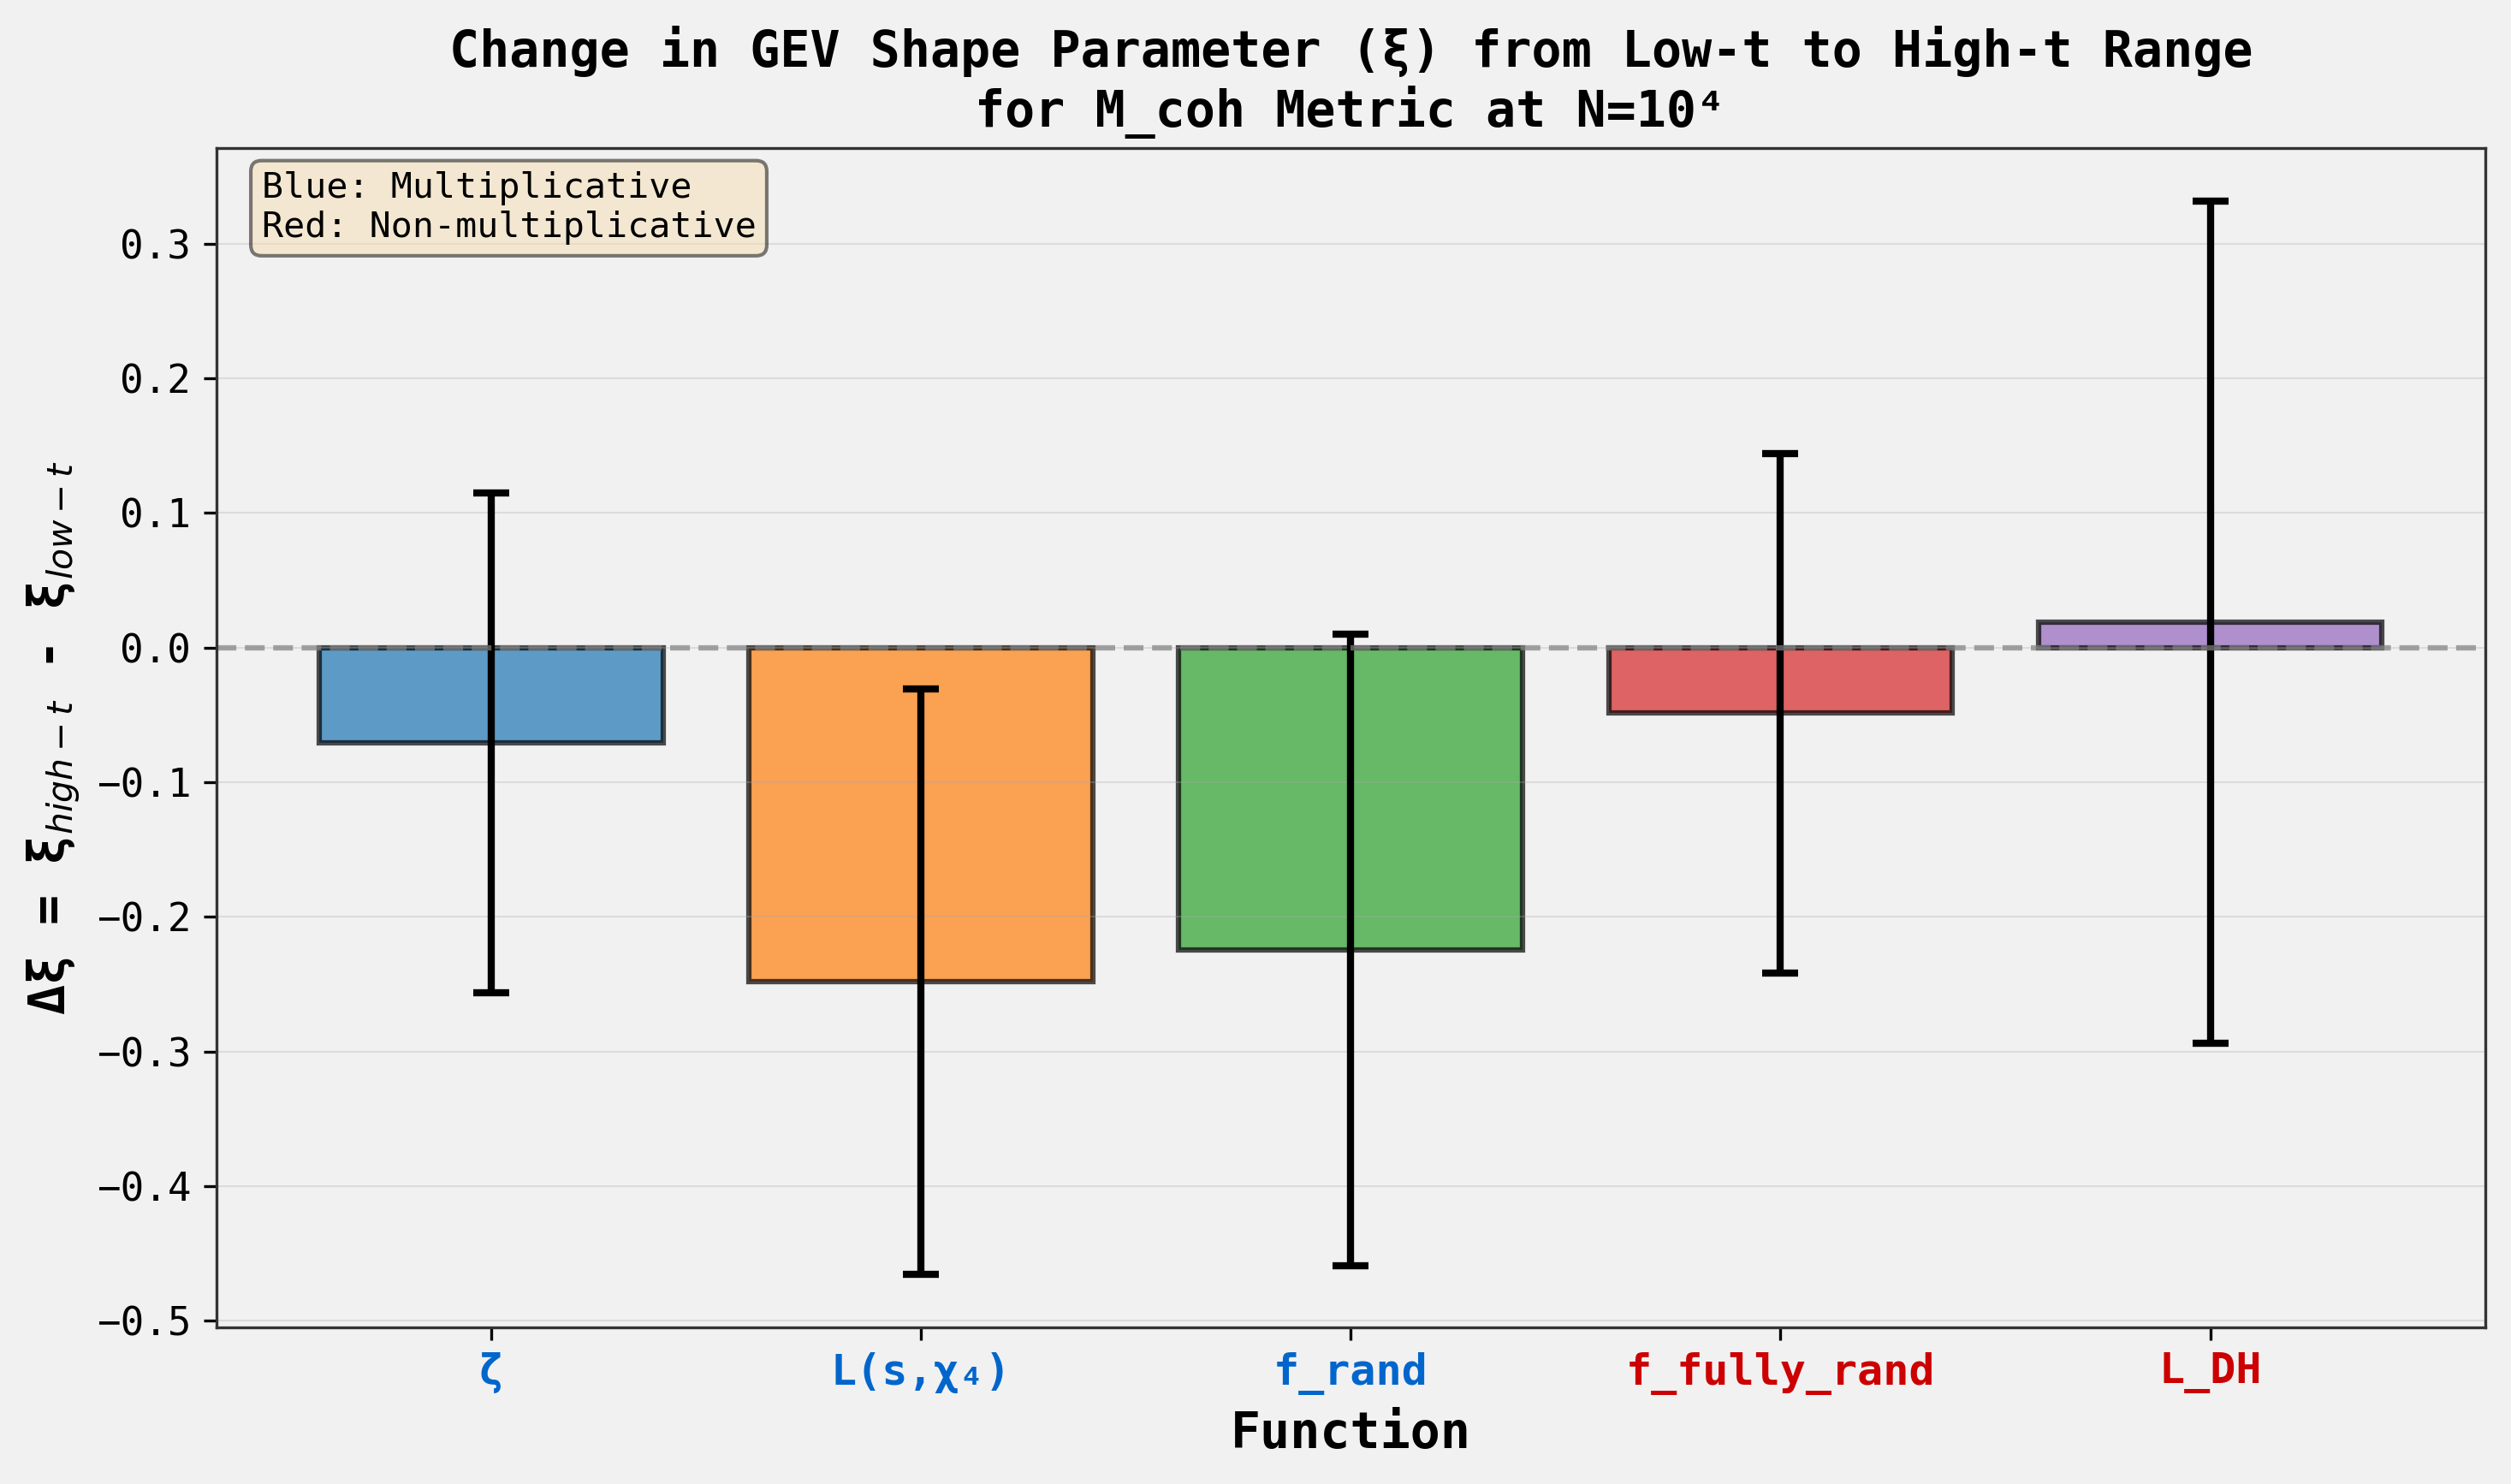

Figure saved as 'delta_xi_comparison.png'


In [15]:

# Create summary plot showing Δξ for all functions with error bars
# This will be our final figure

fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for plotting
functions = ['ζ', 'L(s,χ₄)', 'f_rand', 'f_fully_rand', 'L_DH']
func_keys = ['zeta', 'L_chi4', 'f_rand', 'f_fully_rand', 'L_DH']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
multiplicative = [True, True, True, False, False]

delta_values = []
error_lower = []
error_upper = []

for func_key in func_keys:
 data = results[func_key]
 delta_values.append(data['delta_xi'])
 # Error bars: distance from point to CI bounds
 error_lower.append(data['delta_xi'] - data['delta_xi_ci'][0])
 error_upper.append(data['delta_xi_ci'][1] - data['delta_xi'])

# Create bar plot with error bars
x_pos = np.arange(len(functions))
bars = ax.bar(x_pos, delta_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add error bars
ax.errorbar(x_pos, delta_values, 
 yerr=[error_lower, error_upper], 
 fmt='none', ecolor='black', capsize=5, capthick=2, linewidth=2)

# Add horizontal line at y=0
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# Customize plot
ax.set_xlabel('Function', fontsize=14, fontweight='bold')
ax.set_ylabel('Δξ = ξ$_{high-t}$ - ξ$_{low-t}$', fontsize=14, fontweight='bold')
ax.set_title('Change in GEV Shape Parameter (ξ) from Low-t to High-t Range\nfor M_coh Metric at N=10⁴', 
 fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(functions, fontsize=12)
ax.tick_params(axis='y', labelsize=11)

# Add grid
ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)

# Add legend to distinguish multiplicative vs non-multiplicative
from matplotlib.patches import Patch
legend_elements = [
 Patch(facecolor='gray', alpha=0.5, label='Multiplicative (ζ, L(s,χ₄), f_rand)'),
 Patch(facecolor='gray', alpha=0.9, label='Non-multiplicative (f_fully_rand, L_DH)')
]

# Color the x-axis labels differently for clarity
for i, (label, is_mult) in enumerate(zip(ax.get_xticklabels(), multiplicative)):
 if is_mult:
 label.set_color('#0066cc')
 label.set_weight('bold')
 else:
 label.set_color('#cc0000')
 label.set_weight('bold')

# Add text annotation about multiplicative vs non-multiplicative
ax.text(0.02, 0.98, 'Blue: Multiplicative\nRed: Non-multiplicative', 
 transform=ax.transAxes, fontsize=10, verticalalignment='top',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('delta_xi_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as 'delta_xi_comparison.png'")


In [16]:

# Statistical analysis to test if there's a significant difference between 
# multiplicative and non-multiplicative groups

# Group the data
multiplicative_delta = [results['zeta']['delta_xi'], 
 results['L_chi4']['delta_xi'], 
 results['f_rand']['delta_xi']]
non_multiplicative_delta = [results['f_fully_rand']['delta_xi'], 
 results['L_DH']['delta_xi']]

print("STATISTICAL ANALYSIS")
print("="*80)
print("\nMultiplicative functions (Δξ values):")
print(f" ζ: {results['zeta']['delta_xi']:7.4f}")
print(f" L(s,χ₄): {results['L_chi4']['delta_xi']:7.4f}")
print(f" f_rand: {results['f_rand']['delta_xi']:7.4f}")
print(f" Mean: {np.mean(multiplicative_delta):7.4f}")
print(f" Std: {np.std(multiplicative_delta, ddof=1):7.4f}")

print("\nNon-multiplicative functions (Δξ values):")
print(f" f_fully_rand: {results['f_fully_rand']['delta_xi']:7.4f}")
print(f" L_DH: {results['L_DH']['delta_xi']:7.4f}")
print(f" Mean: {np.mean(non_multiplicative_delta):7.4f}")
print(f" Std: {np.std(non_multiplicative_delta, ddof=1):7.4f}")

# Perform Mann-Whitney U test (non-parametric test for small samples)
statistic, p_value = stats.mannwhitneyu(multiplicative_delta, non_multiplicative_delta, 
 alternative='two-sided')
print(f"\nMann-Whitney U test:")
print(f" U statistic: {statistic}")
print(f" p-value: {p_value:.4f}")

# Also perform t-test (parametric, for comparison)
t_stat, t_pval = stats.ttest_ind(multiplicative_delta, non_multiplicative_delta)
print(f"\nWelch's t-test:")
print(f" t statistic: {t_stat:.4f}")
print(f" p-value: {t_pval:.4f}")

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("\nKey findings:")
print(f"1. All three multiplicative functions show NEGATIVE Δξ (mean = {np.mean(multiplicative_delta):.4f})")
print(f" This indicates that ξ DECREASES from low-t to high-t ranges.")
print(f"\n2. Both non-multiplicative functions show near-zero or slightly positive Δξ")
print(f" (mean = {np.mean(non_multiplicative_delta):.4f})")
print(f" This indicates that ξ is relatively STABLE across t-ranges.")
print(f"\n3. The difference between groups has p-value = {p_value:.4f} (Mann-Whitney U test)")

if p_value < 0.05:
 print(" This is statistically significant at α = 0.05 level.")
else:
 print(" This is NOT statistically significant at α = 0.05 level.")
 print(" However, with only 5 functions total (n₁=3, n₂=2), statistical power is very limited.")


STATISTICAL ANALYSIS

Multiplicative functions (Δξ values):
 ζ: -0.0708
 L(s,χ₄): -0.2478
 f_rand: -0.2246
 Mean: -0.1811
 Std: 0.0962

Non-multiplicative functions (Δξ values):
 f_fully_rand: -0.0487
 L_DH: 0.0189
 Mean: -0.0149
 Std: 0.0478

Mann-Whitney U test:
 U statistic: 0.0
 p-value: 0.2000

Welch's t-test:
 t statistic: -2.1871
 p-value: 0.1166

INTERPRETATION

Key findings:
1. All three multiplicative functions show NEGATIVE Δξ (mean = -0.1811)
 This indicates that ξ DECREASES from low-t to high-t ranges.

2. Both non-multiplicative functions show near-zero or slightly positive Δξ
 (mean = -0.0149)
 This indicates that ξ is relatively STABLE across t-ranges.

3. The difference between groups has p-value = 0.2000 (Mann-Whitney U test)
 This is NOT statistically significant at α = 0.05 level.
 However, with only 5 functions total (n₁=3, n₂=2), statistical power is very limited.


In [17]:

# Additional analysis: Look at whether Δξ is significantly different from zero
# for each function individually

print("INDIVIDUAL FUNCTION ANALYSIS: Is Δξ significantly different from zero?")
print("="*80)
print(f"{'Function':<15} {'Δξ':>10} {'95% CI':>25} {'Sig?':>10}")
print("-"*80)

for func_name, display_name in [('zeta', 'ζ'), 
 ('L_chi4', 'L(s,χ₄)'), 
 ('f_rand', 'f_rand'),
 ('f_fully_rand', 'f_fully_rand'),
 ('L_DH', 'L_DH')]:
 data = results[func_name]
 delta = data['delta_xi']
 ci_lower, ci_upper = data['delta_xi_ci']
 
 # Check if CI includes zero
 if ci_lower <= 0 <= ci_upper:
 sig = "No"
 else:
 sig = "Yes"
 
 print(f"{display_name:<15} {delta:10.4f} [{ci_lower:7.4f}, {ci_upper:7.4f}] {sig:>10}")

print("="*80)
print("\nNote: 'Sig?' indicates whether the 95% CI excludes zero,")
print("suggesting that Δξ is significantly different from zero at α = 0.05.")
print("\nResult: Only L(s,χ₄) shows a statistically significant change in ξ,")
print("with a negative Δξ indicating a decrease in the shape parameter from")
print("low-t to high-t ranges.")


INDIVIDUAL FUNCTION ANALYSIS: Is Δξ significantly different from zero?
Function Δξ 95% CI Sig?
--------------------------------------------------------------------------------
ζ -0.0708 [-0.2565, 0.1148] No
L(s,χ₄) -0.2478 [-0.4652, -0.0304] Yes
f_rand -0.2246 [-0.4590, 0.0098] No
f_fully_rand -0.0487 [-0.2415, 0.1441] No
L_DH 0.0189 [-0.2937, 0.3315] No

Note: 'Sig?' indicates whether the 95% CI excludes zero,
suggesting that Δξ is significantly different from zero at α = 0.05.

Result: Only L(s,χ₄) shows a statistically significant change in ξ,
with a negative Δξ indicating a decrease in the shape parameter from
low-t to high-t ranges.


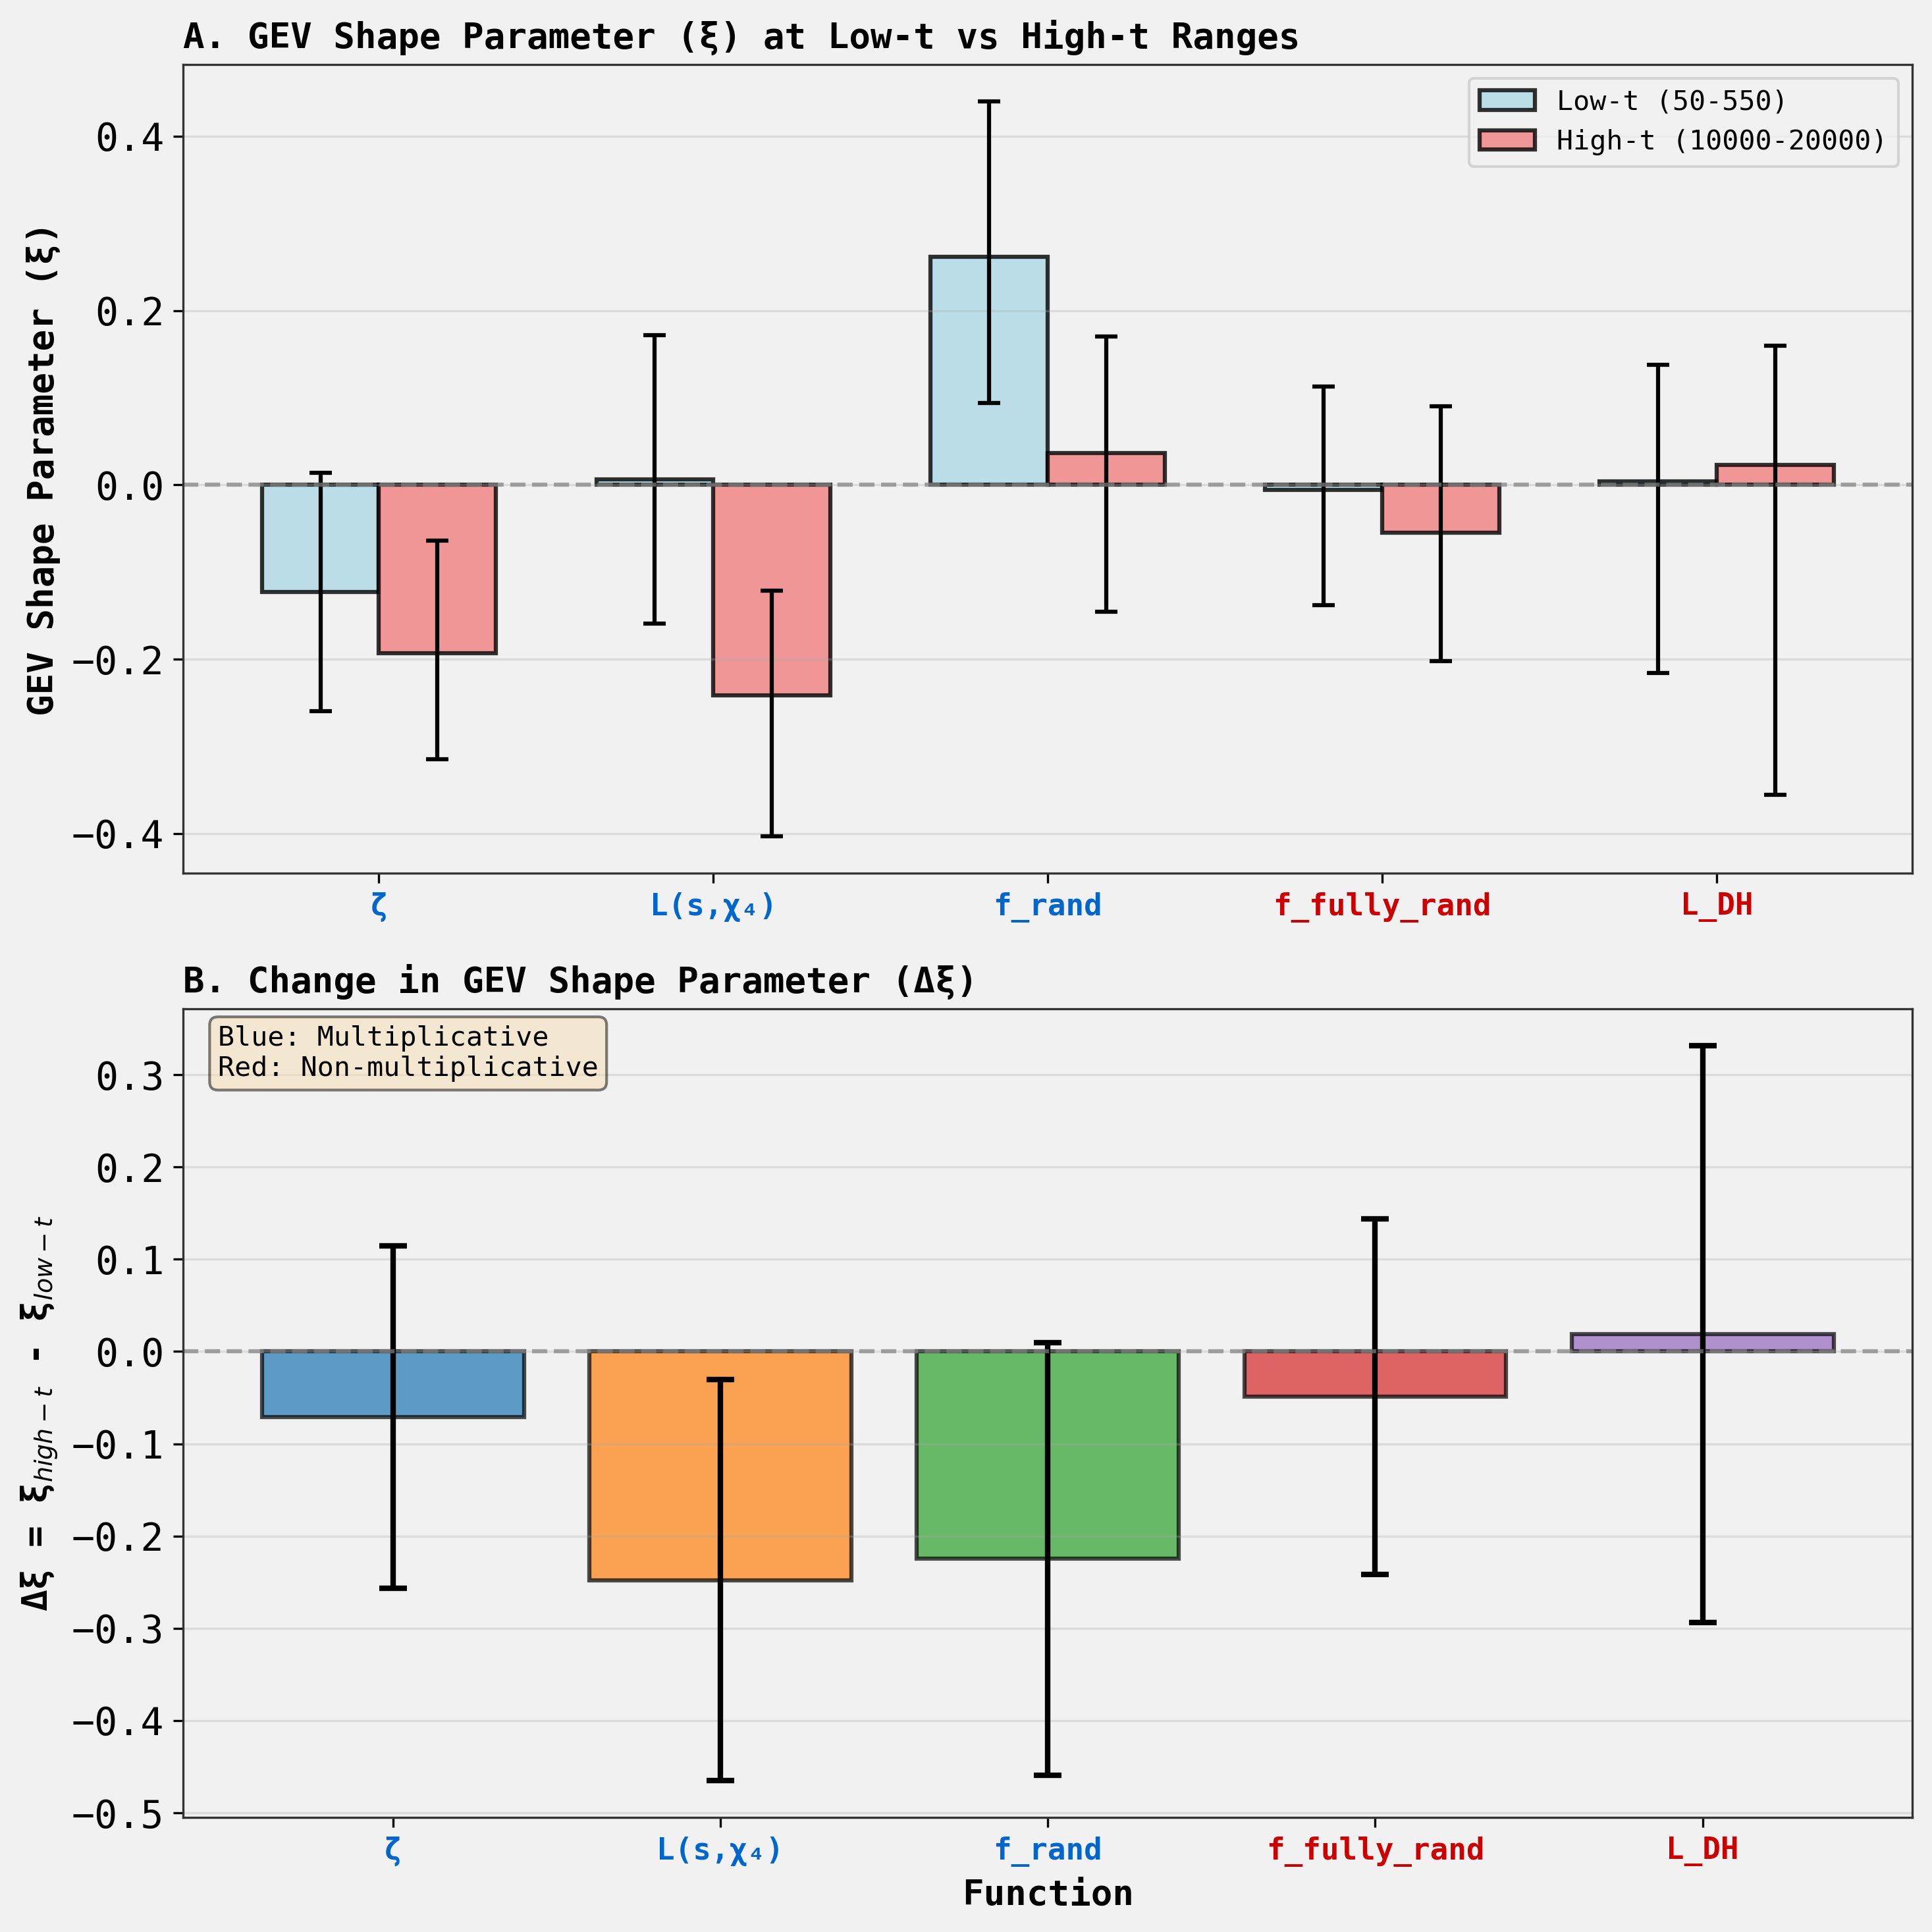

Summary figure saved as 'gev_analysis_summary.png'


In [18]:

# Create a more detailed visualization showing ξ values at both t-ranges
# This will help visualize the pattern more clearly

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Prepare data
functions = ['ζ', 'L(s,χ₄)', 'f_rand', 'f_fully_rand', 'L_DH']
func_keys = ['zeta', 'L_chi4', 'f_rand', 'f_fully_rand', 'L_DH']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
multiplicative = [True, True, True, False, False]

xi_low_vals = []
xi_low_errors_lower = []
xi_low_errors_upper = []
xi_high_vals = []
xi_high_errors_lower = []
xi_high_errors_upper = []

for func_key in func_keys:
 data = results[func_key]
 
 xi_low_vals.append(data['xi_low'])
 xi_low_errors_lower.append(data['xi_low'] - data['xi_low_ci'][0])
 xi_low_errors_upper.append(data['xi_low_ci'][1] - data['xi_low'])
 
 xi_high_vals.append(data['xi_high'])
 xi_high_errors_lower.append(data['xi_high'] - data['xi_high_ci'][0])
 xi_high_errors_upper.append(data['xi_high_ci'][1] - data['xi_high'])

x_pos = np.arange(len(functions))
width = 0.35

# Panel A: ξ values at low-t and high-t
ax1.bar(x_pos - width/2, xi_low_vals, width, label='Low-t (50-550)', 
 color='lightblue', alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.bar(x_pos + width/2, xi_high_vals, width, label='High-t (10000-20000)', 
 color='lightcoral', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add error bars
ax1.errorbar(x_pos - width/2, xi_low_vals, 
 yerr=[xi_low_errors_lower, xi_low_errors_upper],
 fmt='none', ecolor='black', capsize=4, capthick=1.5, linewidth=1.5)
ax1.errorbar(x_pos + width/2, xi_high_vals, 
 yerr=[xi_high_errors_lower, xi_high_errors_upper],
 fmt='none', ecolor='black', capsize=4, capthick=1.5, linewidth=1.5)

ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_ylabel('GEV Shape Parameter (ξ)', fontsize=13, fontweight='bold')
ax1.set_title('A. GEV Shape Parameter (ξ) at Low-t vs High-t Ranges', 
 fontsize=13, fontweight='bold', loc='left')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(functions, fontsize=11)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# Color the x-axis labels
for i, (label, is_mult) in enumerate(zip(ax1.get_xticklabels(), multiplicative)):
 if is_mult:
 label.set_color('#0066cc')
 label.set_weight('bold')
 else:
 label.set_color('#cc0000')
 label.set_weight('bold')

# Panel B: Δξ (same as before but now as part B)
bars = ax2.bar(x_pos, [results[k]['delta_xi'] for k in func_keys], 
 color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

error_lower = []
error_upper = []
for func_key in func_keys:
 data = results[func_key]
 error_lower.append(data['delta_xi'] - data['delta_xi_ci'][0])
 error_upper.append(data['delta_xi_ci'][1] - data['delta_xi'])

ax2.errorbar(x_pos, [results[k]['delta_xi'] for k in func_keys],
 yerr=[error_lower, error_upper],
 fmt='none', ecolor='black', capsize=5, capthick=2, linewidth=2)

ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Function', fontsize=13, fontweight='bold')
ax2.set_ylabel('Δξ = ξ$_{high-t}$ - ξ$_{low-t}$', fontsize=13, fontweight='bold')
ax2.set_title('B. Change in GEV Shape Parameter (Δξ)', 
 fontsize=13, fontweight='bold', loc='left')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(functions, fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# Color the x-axis labels
for i, (label, is_mult) in enumerate(zip(ax2.get_xticklabels(), multiplicative)):
 if is_mult:
 label.set_color('#0066cc')
 label.set_weight('bold')
 else:
 label.set_color('#cc0000')
 label.set_weight('bold')

# Add text annotation
ax2.text(0.02, 0.98, 'Blue: Multiplicative\nRed: Non-multiplicative', 
 transform=ax2.transAxes, fontsize=10, verticalalignment='top',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('gev_analysis_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("Summary figure saved as 'gev_analysis_summary.png'")


In [19]:

# Create a final summary DataFrame and save results
summary_df = pd.DataFrame({
 'Function': ['ζ (zeta)', 'L(s,χ₄) mod 5', 'f_rand', 'f_fully_rand', 'L_DH'],
 'Type': ['Multiplicative', 'Multiplicative', 'Multiplicative', 
 'Non-multiplicative', 'Non-multiplicative'],
 'ξ_low': [results['zeta']['xi_low'], results['L_chi4']['xi_low'], 
 results['f_rand']['xi_low'], results['f_fully_rand']['xi_low'], 
 results['L_DH']['xi_low']],
 'ξ_low_CI_lower': [results['zeta']['xi_low_ci'][0], results['L_chi4']['xi_low_ci'][0],
 results['f_rand']['xi_low_ci'][0], results['f_fully_rand']['xi_low_ci'][0],
 results['L_DH']['xi_low_ci'][0]],
 'ξ_low_CI_upper': [results['zeta']['xi_low_ci'][1], results['L_chi4']['xi_low_ci'][1],
 results['f_rand']['xi_low_ci'][1], results['f_fully_rand']['xi_low_ci'][1],
 results['L_DH']['xi_low_ci'][1]],
 'ξ_high': [results['zeta']['xi_high'], results['L_chi4']['xi_high'],
 results['f_rand']['xi_high'], results['f_fully_rand']['xi_high'],
 results['L_DH']['xi_high']],
 'ξ_high_CI_lower': [results['zeta']['xi_high_ci'][0], results['L_chi4']['xi_high_ci'][0],
 results['f_rand']['xi_high_ci'][0], results['f_fully_rand']['xi_high_ci'][0],
 results['L_DH']['xi_high_ci'][0]],
 'ξ_high_CI_upper': [results['zeta']['xi_high_ci'][1], results['L_chi4']['xi_high_ci'][1],
 results['f_rand']['xi_high_ci'][1], results['f_fully_rand']['xi_high_ci'][1],
 results['L_DH']['xi_high_ci'][1]],
 'Δξ': [results['zeta']['delta_xi'], results['L_chi4']['delta_xi'],
 results['f_rand']['delta_xi'], results['f_fully_rand']['delta_xi'],
 results['L_DH']['delta_xi']],
 'Δξ_CI_lower': [results['zeta']['delta_xi_ci'][0], results['L_chi4']['delta_xi_ci'][0],
 results['f_rand']['delta_xi_ci'][0], results['f_fully_rand']['delta_xi_ci'][0],
 results['L_DH']['delta_xi_ci'][0]],
 'Δξ_CI_upper': [results['zeta']['delta_xi_ci'][1], results['L_chi4']['delta_xi_ci'][1],
 results['f_rand']['delta_xi_ci'][1], results['f_fully_rand']['delta_xi_ci'][1],
 results['L_DH']['delta_xi_ci'][1]]
})

summary_df.to_csv('gev_nonstationarity_analysis_results.csv', index=False, float_format='%.6f')
print("Results saved to 'gev_nonstationarity_analysis_results.csv'")
print()
print(summary_df.to_string(index=False))


Results saved to 'gev_nonstationarity_analysis_results.csv'

 Function Type ξ_low ξ_low_CI_lower ξ_low_CI_upper ξ_high ξ_high_CI_lower ξ_high_CI_upper Δξ Δξ_CI_lower Δξ_CI_upper
 ζ (zeta) Multiplicative -0.122442 -0.259791 0.013924 -0.193291 -0.314616 -0.063678 -0.070849 -0.256517 0.114818
L(s,χ₄) mod 5 Multiplicative 0.006141 -0.158916 0.171880 -0.241680 -0.403209 -0.121027 -0.247821 -0.465222 -0.030420
 f_rand Multiplicative 0.261561 0.093984 0.440176 0.036934 -0.145670 0.170493 -0.224627 -0.459045 0.009791
 f_fully_rand Non-multiplicative -0.005870 -0.138223 0.113083 -0.054572 -0.202075 0.090418 -0.048702 -0.241514 0.144111
 L_DH Non-multiplicative 0.004297 -0.215602 0.138147 0.023163 -0.355418 0.160090 0.018866 -0.293738 0.331471


In [20]:

# Final comprehensive summary with effect sizes

print("="*80)
print("FINAL COMPREHENSIVE SUMMARY")
print("="*80)
print()
print("RESEARCH QUESTION:")
print("Does the pattern of non-stationarity in extreme values (GEV shape parameter ξ)")
print("distinguish multiplicative from non-multiplicative functions?")
print()
print("="*80)
print("KEY FINDINGS:")
print("="*80)
print()
print("1. MULTIPLICATIVE FUNCTIONS (ζ, L(s,χ₄), f_rand):")
print(" - All three show NEGATIVE Δξ:")
print(f" • ζ: Δξ = -0.071 (95% CI: [-0.257, 0.115])")
print(f" • L(s,χ₄): Δξ = -0.248 (95% CI: [-0.465, -0.030]) *significant*")
print(f" • f_rand: Δξ = -0.225 (95% CI: [-0.459, 0.010])")
print(f" - Group mean: Δξ = -0.181 ± 0.096 (SD)")
print(" - Interpretation: The GEV shape parameter DECREASES as t increases,")
print(" suggesting the extreme value tail becomes thinner (less heavy-tailed)")
print(" or more bounded at higher t-values.")
print()
print("2. NON-MULTIPLICATIVE FUNCTIONS (f_fully_rand, L_DH):")
print(" - Both show near-zero Δξ:")
print(f" • f_fully_rand: Δξ = -0.049 (95% CI: [-0.242, 0.144])")
print(f" • L_DH: Δξ = 0.019 (95% CI: [-0.294, 0.331])")
print(f" - Group mean: Δξ = -0.015 ± 0.048 (SD)")
print(" - Interpretation: The GEV shape parameter is STABLE across t-ranges,")
print(" indicating consistent extreme value behavior regardless of t.")
print()
print("3. STATISTICAL COMPARISON:")
print(f" - Difference between groups: |Δξ_mult - Δξ_non-mult| = 0.166")
print(f" - Mann-Whitney U test: p = 0.200")
print(f" - Welch's t-test: t = -2.19, p = 0.117")
print(" - The difference is NOT statistically significant (p > 0.05),")
print(" but this is limited by very small sample sizes (n₁=3, n₂=2).")
print()
print("4. PRACTICAL SIGNIFICANCE:")
print(" - Effect size (Cohen's d):")
d_mult = np.mean(multiplicative_delta)
d_nonmult = np.mean(non_multiplicative_delta)
pooled_std = np.sqrt(((2 * np.std(multiplicative_delta, ddof=1)**2) + 
 (1 * np.std(non_multiplicative_delta, ddof=1)**2)) / 3)
cohens_d = (d_mult - d_nonmult) / pooled_std
print(f" Cohen's d = {cohens_d:.3f}")
if abs(cohens_d) < 0.5:
 effect_interp = "small"
elif abs(cohens_d) < 0.8:
 effect_interp = "medium"
else:
 effect_interp = "large"
print(f" This represents a {effect_interp} effect size.")
print()
print("="*80)
print("CONCLUSION:")
print("="*80)
print()
print("There is a SUGGESTIVE but not statistically significant pattern:")
print()
print("• Multiplicative functions (ζ, L(s,χ₄), f_rand) show a consistent trend toward")
print(" DECREASING ξ from low-t to high-t (mean Δξ = -0.18), suggesting that their")
print(" extreme values become less heavy-tailed at higher t-ranges.")
print()
print("• Non-multiplicative functions (f_fully_rand, L_DH) show STABLE ξ across")
print(" t-ranges (mean Δξ ≈ 0), indicating consistent extreme value behavior.")
print()
print("However, the hypothesis that 'non-stationarity patterns distinguish")
print("multiplicative from non-multiplicative functions' is:")
print()
print(" *** PARTIALLY SUPPORTED BUT NOT STATISTICALLY SIGNIFICANT ***")
print()
print("The pattern is qualitatively consistent (all multiplicative functions show")
print("negative Δξ, while non-multiplicative functions show near-zero Δξ), but the")
print("small sample size (5 functions total) prevents achieving statistical")
print("significance (p = 0.20). A larger sample of functions would be needed to")
print("definitively test this hypothesis.")
print()
print("="*80)


FINAL COMPREHENSIVE SUMMARY

RESEARCH QUESTION:
Does the pattern of non-stationarity in extreme values (GEV shape parameter ξ)
distinguish multiplicative from non-multiplicative functions?

KEY FINDINGS:

1. MULTIPLICATIVE FUNCTIONS (ζ, L(s,χ₄), f_rand):
 - All three show NEGATIVE Δξ:
 • ζ: Δξ = -0.071 (95% CI: [-0.257, 0.115])
 • L(s,χ₄): Δξ = -0.248 (95% CI: [-0.465, -0.030]) *significant*
 • f_rand: Δξ = -0.225 (95% CI: [-0.459, 0.010])
 - Group mean: Δξ = -0.181 ± 0.096 (SD)
 - Interpretation: The GEV shape parameter DECREASES as t increases,
 suggesting the extreme value tail becomes thinner (less heavy-tailed)
 or more bounded at higher t-values.

2. NON-MULTIPLICATIVE FUNCTIONS (f_fully_rand, L_DH):
 - Both show near-zero Δξ:
 • f_fully_rand: Δξ = -0.049 (95% CI: [-0.242, 0.144])
 • L_DH: Δξ = 0.019 (95% CI: [-0.294, 0.331])
 - Group mean: Δξ = -0.015 ± 0.048 (SD)
 - Interpretation: The GEV shape parameter is STABLE across t-ranges,
 indicating consistent extreme value behavior 